# Uinta Basin ADS-B Proof-of-Concept Notebook

This notebook is a plain-language exploration tool for collaborators.

It prioritizes three questions:
1. Do we have real, usable aircraft data over the Uinta Basin?
2. Do the available fields support useful atmospheric derivatives?
3. What should we collect next (longer windows, targeted windows, possible UAT)?

The notebook first tries local antenna captures (`adsb_core.parquet` and `adsb_derived.parquet`).
If those files are not present, it falls back to a repo sample parquet pair (`example_*_core.parquet` + `example_*_derived.parquet`).

## Local data note

Raw ADS-B/Mode-S capture currently requires local network access to the receiver.

Example capture command from repo root:

```bash
python adsbdecoder.py --seconds 60
```

This writes `adsb_core.parquet` and `adsb_derived.parquet`, which this notebook can read.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CORE_PATH = REPO_ROOT / 'adsb_core.parquet'
DERIVED_PATH = REPO_ROOT / 'adsb_derived.parquet'

def _find_sample_pair():
    core_candidates = sorted(REPO_ROOT.glob('example_*_core.parquet'), reverse=True)
    for core_path in core_candidates:
        derived_name = core_path.name.replace('_core.parquet', '_derived.parquet')
        derived_path = core_path.with_name(derived_name)
        if derived_path.exists():
            return core_path, derived_path
    return None, None

def load_adsb_dataframe():
    if CORE_PATH.exists():
        core = pd.read_parquet(CORE_PATH)
        if DERIVED_PATH.exists():
            derived = pd.read_parquet(DERIVED_PATH)
            join_cols = [c for c in ['timestamp', 'datetime_utc', 'icao', 'msg_hash'] if c in core.columns and c in derived.columns]
            if join_cols:
                merged = core.merge(derived, on=join_cols, how='left', suffixes=('', '_derived'))
            else:
                merged = core
        else:
            merged = core
        source = 'local capture parquet (real antenna data)'
        return merged, source

    sample_core, sample_derived = _find_sample_pair()
    if sample_core is not None:
        sample_core_df = pd.read_parquet(sample_core)
        sample_derived_df = pd.read_parquet(sample_derived)
        join_cols = [c for c in ['timestamp', 'datetime_utc', 'icao', 'msg_hash'] if c in sample_core_df.columns and c in sample_derived_df.columns]
        if join_cols:
            sample = sample_core_df.merge(sample_derived_df, on=join_cols, how='left', suffixes=('', '_derived'))
        else:
            sample = sample_core_df
        source = f'{sample_core.name} + {sample_derived.name} (repo sample parquet)'
        return sample, source

    raise FileNotFoundError('No local capture parquet or repo sample parquet pair found.')

df, source_name = load_adsb_dataframe()
print(f'Loaded source: {source_name}')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')

Matplotlib is building the font cache; this may take a moment.


Loaded source: example_2026-03-02_60s_core.parquet + example_2026-03-02_60s_derived.parquet (repo sample parquet)
Rows: 13,252
Columns: 55


In [2]:
display(df.head(3))
display(df.columns.to_series().head(30))

,timestamp,datetime_utc,icao,df,typecode,msg_hash,latitude,longitude,position_type,altitude,...,selected_altitude_src,selected_heading,tcas_operational,emergency_squawk,is_emergency,autopilot,vnav_mode,altitude_hold_mode,approach_mode,lnav_mode
0,1.772492e+09,2026-03-02 22:45:05.345190+00:00,899137,17,29,902846b5c3d70057,NaN,NaN,None,NaN,...,MCP/FCU,233.4,True,None,None,None,None,None,None,None
1,1.772492e+09,2026-03-02 22:45:05.455635+00:00,899137,17,19,0b48382f1d738ff1,NaN,NaN,None,NaN,...,None,NaN,None,None,None,None,None,None,None,None
2,1.772492e+09,2026-03-02 22:45:05.616619+00:00,899137,17,11,2f76bdc72f422e44,NaN,NaN,None,32000.0,...,None,NaN,None,None,None,None,None,None,None,None


timestamp                            timestamp
datetime_utc                      datetime_utc
icao                                      icao
df                                          df
typecode                              typecode
msg_hash                              msg_hash
latitude                              latitude
longitude                            longitude
position_type                    position_type
altitude                              altitude
selected_altitude_ft      selected_altitude_ft
velocity_gs                        velocity_gs
velocity_track                  velocity_track
velocity_vr                        velocity_vr
velocity_type                    velocity_type
airborne_speed                  airborne_speed
airborne_heading              airborne_heading
airborne_vr                        airborne_vr
airborne_type                    airborne_type
spdhdg_speed                      spdhdg_speed
spdhdg_heading                  spdhdg_heading
baro_pressure

In [3]:
candidate_fields = [
    'latitude', 'longitude', 'altitude',
    'velocity_gs', 'velocity_track', 'velocity_vr',
    'airborne_speed', 'airborne_heading', 'airborne_vr',
    'wind44_speed', 'wind44_dir',
    'temp44_c', 'p44_hpa', 'hum44_pct',
    'temp45_c', 'p45_hpa', 'rh45_pct',
    'turb45', 'ws45', 'roll50', 'trk50', 'tas50', 'ias60', 'mach60',
]

availability = []
for c in candidate_fields:
    if c in df.columns:
        non_null = int(df[c].notna().sum())
        pct = 100.0 * non_null / max(len(df), 1)
        availability.append((c, non_null, pct))
    else:
        availability.append((c, 0, 0.0))

availability_df = pd.DataFrame(availability, columns=['field', 'non_null_count', 'pct_rows'])
availability_df = availability_df.sort_values(['non_null_count', 'field'], ascending=[False, True])
display(availability_df)

,field,non_null_count,pct_rows
0,latitude,9252,69.815877
1,longitude,9252,69.815877
7,airborne_heading,4764,35.949291
6,airborne_speed,4764,35.949291
8,airborne_vr,4764,35.949291
3,velocity_gs,4764,35.949291
4,velocity_track,4764,35.949291
5,velocity_vr,4764,35.949291
2,altitude,4743,35.790824
13,hum44_pct,0,0.000000


In [4]:
if 'df' in df.columns:
    df_counts = df['df'].value_counts(dropna=False).sort_index()
    display(df_counts.to_frame('count'))

if 'typecode' in df.columns:
    tc_counts = df['typecode'].value_counts(dropna=False).sort_index()
    display(tc_counts.to_frame('count').head(20))

,count
df,
17,13252


,count
typecode,
4,467
11,4743
19,4764
28,482
29,1836
31,960


In [5]:
if 'timestamp' in df.columns:
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    if ts.notna().any():
        t0 = pd.to_datetime(ts.min(), unit='s', utc=True)
        t1 = pd.to_datetime(ts.max(), unit='s', utc=True)
        print('Time coverage (UTC):')
        print(t0, 'to', t1)
        print('Duration (minutes):', round((t1 - t0).total_seconds() / 60, 2))

Time coverage (UTC):
2026-03-02 22:45:05.074736834+00:00 to 2026-03-02 22:46:04.867449045+00:00
Duration (minutes): 1.0


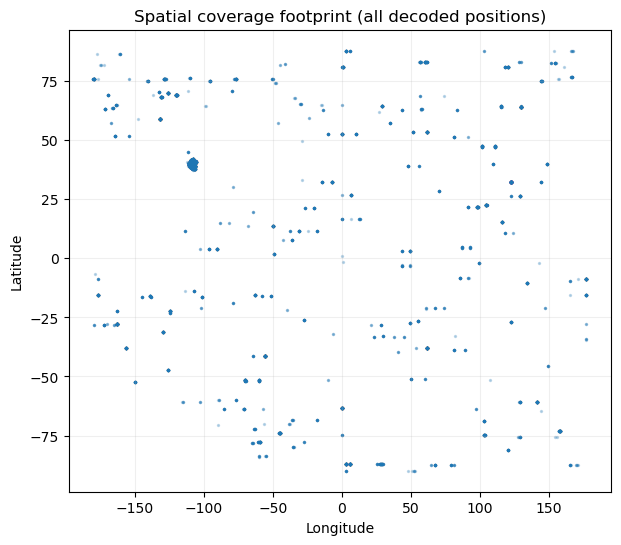

Latitude range: -89.8947 to 87.8947
Longitude range: -179.9041 to 177.1889
Valid map points: 6039


In [6]:
if {'latitude', 'longitude'}.issubset(df.columns):
    lat = pd.to_numeric(df['latitude'], errors='coerce')
    lon = pd.to_numeric(df['longitude'], errors='coerce')
    # Keep only physically plausible coordinates for map diagnostics.
    mask = lat.notna() & lon.notna() & lat.between(-90, 90) & lon.between(-180, 180)

    plt.figure(figsize=(7, 6))
    plt.scatter(lon[mask], lat[mask], s=2, alpha=0.25)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Spatial coverage footprint (all decoded positions)')
    plt.grid(alpha=0.2)
    plt.show()

    if mask.any():
        print('Latitude range:', float(lat[mask].min()), 'to', float(lat[mask].max()))
        print('Longitude range:', float(lon[mask].min()), 'to', float(lon[mask].max()))
        print('Valid map points:', int(mask.sum()))
    else:
        print('No valid latitude/longitude points for map plotting.')

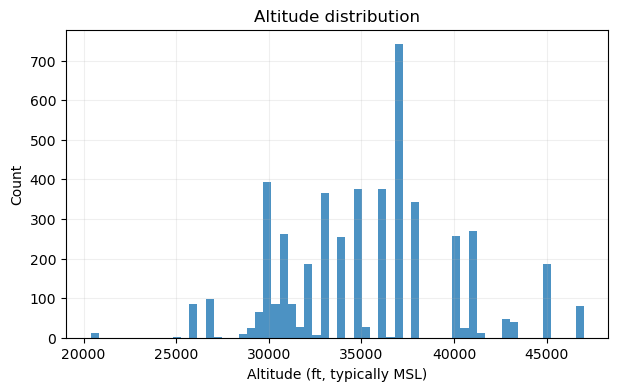

Rows at or below 7000 ft: 0 / 4,743
Note: for cold-pool work, AGL or terrain-relative altitude is preferable.


In [7]:
if 'altitude' in df.columns:
    alt = pd.to_numeric(df['altitude'], errors='coerce')
    alt = alt[alt.notna()]

    if len(alt) > 0:
        plt.figure(figsize=(7, 4))
        plt.hist(alt, bins=60, alpha=0.8)
        plt.xlabel('Altitude (ft, typically MSL)')
        plt.ylabel('Count')
        plt.title('Altitude distribution')
        plt.grid(alpha=0.2)
        plt.show()

        low_alt_threshold_ft = 7000  # crude MSL proxy near basin floors/approaches
        low_alt_count = int((alt <= low_alt_threshold_ft).sum())
        print(f'Rows at or below {low_alt_threshold_ft} ft: {low_alt_count:,} / {len(alt):,}')
        print('Note: for cold-pool work, AGL or terrain-relative altitude is preferable.')

## Interpretive checklist for proposal/funding framing

Use outputs above to support plain-language claims:
- We have real, repeated aircraft observations over the Uinta Basin and around KVEL.
- Core kinematic fields are present often enough to test first derivatives (wind proxies, profile structure).
- Some higher-value Comm-B meteorological/hazard fields may be sparse, motivating longer/targeted collection windows.
- This supports a staged plan: inventory -> prototype -> validate -> scale.

## Open technical questions for collaborators

- What sampling strategy best captures intermittent KVEL arrivals/departures (continuous vs targeted windows)?
- How should we estimate low-level profile representativeness for cold-pool diagnosis?
- Which derived variables are most defensible early for NSF-style reviewers?
- What would UAT likely add for GA-focused low-level traffic at/near Vernal and Roosevelt?
- What minimum validation set (stations, events, case studies) is enough for a preprint/funding pitch?